# What a hidden-state score measures after eight traces

**Workshop storyboard: prompt-level abstention, not trace verification.**

*Status: rewritten 2026-08-22 from the three closure experiments committed that
day. Fixed eight-sample Best-of-N on all 500 MATH-500 prompts, three checkpoints,
two reasoning-distilled. Every number below is read out of a committed artifact under
`results/`; the notebook runs no model and fits nothing. The long-form record is
notebook [17](17_rmd_experiment_ledger.ipynb), which loads every closure-era
artifact -- including the seven controls that appear in no other notebook -- and
states the population and sign hazards this storyboard only has room to mention;
`EXPERIMENT_LOG.md` is the protocol record. Notebooks
[12](12_wave1_abstention.ipynb) and
[13](13_deepconf_null_and_label_efficiency.ipynb) keep the pre-closure
abstention, DeepConf and label-efficiency material.*

---

## Paper claim

A reliability signal read off hidden states is routinely evaluated by pooling
every sampled trace and reporting one AUROC. That statistic validly ranks traces
drawn from the deployment mixture, but it does not answer which of one prompt's
own samples is right. It mixes *which prompt is hard* with sibling-level
correctness, and the two are different capabilities with different uses.

Separating them on a fixed eight-sample protocol gives one positive and one
negative result, on the same traces:

1. **Prompt-level abstention: a small, real gain at zero extra generations.**
   Adding a Mahalanobis tail score to target-only output features improves
   selective prediction over all 500 prompts on all three models --
   AURC `B1 - B0` of **-0.0520 / -0.0284 / -0.0469**, every interval excluding
   zero. It needs no additional sampling once the target's states are retained.

2. **Trace verification: the pooled number does not survive conditioning.** A
   supervised last-token probe, reproduced at its strength, reaches pooled trace
   AUROC **0.90 / 0.91 / 0.90** and falls to **0.64 / 0.58 / 0.72** within
   prompt. Both hidden-state probes lose more than entropy and log-probability,
   and on Qwen those output-side scores *gain*. Length also loses substantial
   pooled discrimination, so the collapse is not exclusive to hidden states.

3. **A paid alternative is not uniformly better or worse.** Against a deployable
   peer-agreement baseline bought with one extra generation, the six
   target-peer pairs split 4 ties, 1 win, 1 loss. Buy more of it and the peer
   often wins outright. The exploratory tally over all 36 correlated,
   unadjusted deployable rungs is 16 peer wins, 16 ties, and 4 wins for the
   hidden-state score. What decides it is *which* peer, not how many samples of
   it; the cheap rung is the primary comparison because it is the only one
   matched on order of cost, not because it is the most favourable.

The scope is one dataset, one budget, three checkpoints. The claim is a
prompt-level abstention feature, not a trace verifier and not a mechanism. All
intervals here resample prompts with the fitting path held fixed; the full
outer refit that would carry the fit's own uncertainty is registered in
`EXPERIMENT_LOG.md` (2026-08-22) and is still pending. Section 4 says so where
the number is quoted.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd()))
import _viz_utils as vu

ROOT = vu.repo_root()
sys.path.insert(0, str(ROOT))
from baselines.abstention_baselines import holm_correction

MODELS = ["qwen", "deepseek", "deepseek_llama"]
NICE = {"qwen": "Qwen2.5-7B", "deepseek": "DeepSeek-7B", "deepseek_llama": "Llama-8B"}
PRIMARY = "full_population"  # C_B on all 500 prompts; see section 2


def artifact(relpath):
    """A committed result. Missing means the story moved, not that a default applies."""
    with (ROOT / "results" / relpath).open(encoding="utf-8") as handle:
        return json.load(handle)


BUDGET = artifact("budget_outcomes/budget_outcomes.json")
LADDER = artifact("peer_cost_ladder/peer_cost_ladder_results.json")
PROBE = artifact("last_token_probe/last_token_probe_results.json")
CLOSEST = artifact("closest_baselines/closest_baselines_results.json")

# The refit sweep is registered and pending; the gate in section 4 reads this.
REFIT_PATH = ROOT / "results/refit_stability/refit_stability_results.json"
REFIT_PAYLOAD = json.loads(REFIT_PATH.read_text()) if REFIT_PATH.exists() else {}
REFIT = REFIT_PAYLOAD if REFIT_PAYLOAD.get("complete") else None

# Guard the joins the prose depends on, so a renamed key fails here and not
# silently three figures later.
assert [r["label"] for r in LADDER["models"]] == MODELS
assert set(PROBE["models"]) == set(MODELS)
assert {row["population"] for row in BUDGET["populations"]} >= {
    PRIMARY, "cap_free_valid_plurality"}
# Section 4a reads 1a/1b off the primary population. Before 2026-08-22 this
# artifact held only the cap-free filters, and the assert is what would have
# caught the storyboard quoting a permissive number as the result.
assert [m["label"] for m in CLOSEST["models"]] == MODELS
for _m in CLOSEST["models"]:
    assert PRIMARY in _m["populations"], (_m["label"], "rerun closest_baselines")

# ---------------------------------------------------------------------------
# Presentation only. Nothing below this line touches a number.
# ---------------------------------------------------------------------------
INK, MUTED, PAPER = "#1a1a1a", "#5b5b5b", "#ffffff"
SANS = "-apple-system,BlinkMacSystemFont,Segoe UI,Helvetica,Arial,sans-serif"
GEOMETRY, OUTPUT_SIDE = "#c0392b", "#5b7fa6"
B0_COLOR, B1_COLOR, PEER_COLOR = "#8d99a6", "#c0392b", "#4f9153"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9a9a9a", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

_RULES = [
    {"selector": "", "props": [("border-collapse", "collapse"), ("font-size", "12px")]},
    {"selector": "th", "props": [("text-align", "right"), ("font-weight", "600"),
                                 ("padding", "5px 13px"), ("border", "none"),
                                 ("border-bottom", "1px solid #9a9a9a")]},
    {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 13px"),
                                 ("border", "none")]},
    {"selector": "thead tr", "props": [("border-top", "1.4px solid #222")]},
    {"selector": "tbody tr:last-child td",
     "props": [("border-bottom", "1.4px solid #222")]},
]


def table(frame, title, note=None, highlight=None, **formats):
    """A frame as a ruled table with a title and a reading note."""
    text_cols = [i for i, name in enumerate(frame.columns)
                 if not pd.api.types.is_numeric_dtype(frame[name])]
    styler = (
        frame.style.hide(axis="index")
        .format(formats or None)
        .set_table_styles(_RULES + [
            {"selector": f"{tag}.col{i}", "props": [("text-align", "left")]}
            for i in text_cols for tag in ("th", "td")
        ])
    )
    if highlight is not None:
        styler = styler.apply(
            lambda _col, mask=list(highlight):
                ["background-color: #fbf0da" if flag else "" for flag in mask],
            axis=0,
        )
    head = f"<div style='font:600 13px/1.4 {SANS};margin:0 0 8px'>{title}</div>"
    tail = (f"<div style='font:400 11.5px/1.55 {SANS};color:{MUTED};max-width:780px;"
            f"margin:9px 0 0'>{note}</div>") if note else ""
    display(HTML(f"<div style='background:{PAPER};color:{INK};padding:12px 14px 14px;"
                 f"display:inline-block;font-family:{SANS}'>"
                 f"{head}{styler.to_html()}{tail}</div>"))


CAP = BUDGET["cap_accounting"]
print("model          cap      layer   traces   capped   probe layers   prompts(parseable)")
for label in MODELS:
    cap, probe = CAP[label], PROBE["models"][label]
    parseable = probe["populations"]["parseable"]
    print(f"{label:14s} {cap['max_new_tokens']:>6}  {cap['layer']:>6}  "
          f"{cap['n_traces']:>7}  {cap['n_capped']:>7}   "
          f"{str(probe['layers']):>13}   {parseable['n_prompts']:>6}")
print()
print(f"target budget     {LADDER['cost_model']['target_calls']} generations per prompt")
print(f"B1 extra calls    {LADDER['cost_model']['rmd_extra_calls_over_B0']} "
      f"({LADDER['cost_model']['uncosted']})")
print(f"refit sweep       {'loaded' if REFIT else 'PENDING -- section 4 gate is open'}")

model          cap      layer   traces   capped   probe layers   prompts(parseable)
qwen             1024      21     4000      338     [7, 14, 21]      498
deepseek         8192      21     4000      374     [7, 14, 21]      493
deepseek_llama  12288      24     4000      250     [8, 16, 24]      499

target budget     8 generations per prompt
B1 extra calls    0 (hidden-state retention and the Mahalanobis readout for B1; real work, but not a generation)
refit sweep       PENDING -- section 4 gate is open


## 1. Two questions that one number is asked to answer

Sample eight traces for a MATH-500 prompt and there are two decisions a
reliability score could support.

**Prompt-level abstention.** *Given everything the eight traces produced, should
this prompt's answer be trusted or handed off?* The unit is the prompt, the
outcome is whether the aggregated answer is correct, and the metric is a
selective-prediction curve over 500 prompts.

**Within-prompt trace selection.** *Given these eight traces for one prompt,
which one is right?* The unit is the trace, and only prompts that produced both
a correct and an incorrect trace can inform it at all.

A pooled trace AUROC -- score every held-out trace, ignore which prompt it came
from, take one AUROC -- is reported as if it answered the second. It does not.
A score that is constant inside a prompt and tracks prompt difficulty across
prompts scores high pooled and exactly at chance within prompt. That is a
sharp, testable difference, and section 3 measures it.

The two questions also live on different populations, which is why they cannot
share an interval:

| Readout | Population | Single-outcome prompts |
|:--|:--|:--|
| `pooled` | every held-out trace, prompt identity ignored | their traces are counted |
| `micro` | every within-prompt (correct, incorrect) pair, pair-weighted | contribute no pairs |
| `macro` | per-prompt AUROC, each prompt counted once | undefined, excluded |

On Qwen, 381 of 498 parseable prompts are single-outcome. The within-prompt
readouts rest on the other 117. Every table below prints that count next to the
number it bounds.

## 2. The outcome is defined at a budget, and the budget is part of the claim

"Is this prompt answered correctly?" is not well posed until the sampling budget
is fixed. Every trace here was generated under a token cap -- 1024, 8192 and
12288 for the three models -- and a capped trace has no parsed answer. The
choice of what to do with those prompts moves the headline.

The primary estimand is **`C_B`: correctness at budget `B`, over all 500
prompts, with an unparsed trace scoring 0.** A capped trace is not a missing
observation. It is the protocol's answer -- at this budget, this sample produced
nothing usable -- and dropping it conditions on an outcome of the very budget
being evaluated. The cap-free subset that earlier drafts led with is a
conditional secondary analysis, and Table 1 shows what conditioning buys.

In [2]:
ROWS = pd.DataFrame(BUDGET["populations"])
ORDER = ["full_population", "valid_plurality", "cap_free_valid_plurality",
         "all_eight_parseable"]
ROWS["rank"] = ROWS["population"].map({name: i for i, name in enumerate(ORDER)})
ROWS = ROWS.sort_values(["model", "rank"], key=lambda s: s.map(
    {m: i for i, m in enumerate(MODELS)}) if s.name == "model" else s)

T1 = pd.DataFrame([
    {
        "model": NICE[row["model"]],
        "population": row["population"],
        "definition": row["definition"],
        "prompts": row["n_prompts"],
        "retained": row["retained"],
        "AURC B0": row["aurc_b0"],
        "AURC B1": row["aurc_b1"],
        "B1 - B0": row["delta_estimate"],
        "95% CI": f"[{row['delta_ci_low']:+.4f}, {row['delta_ci_high']:+.4f}]",
        "excludes 0": "yes" if row["excludes_zero"] else "no",
    }
    for _, row in ROWS.iterrows()
])
table(
    T1,
    "Table 1 · the increment on four populations, three models",
    note=("Lower AURC is better. The highlighted rows are the primary estimand: "
          "<code>C_B</code> on all 500 prompts. Every population gives the same "
          "sign and every interval excludes zero, so the choice is not what makes "
          "the effect exist -- it is what sets its size. Intervals resample "
          "prompts with folds, layer and coefficients frozen (section 4)."),
    highlight=[population == PRIMARY for population in T1["population"]],
    **{"retained": "{:.1%}", "AURC B0": "{:.4f}", "AURC B1": "{:.4f}",
       "B1 - B0": "{:+.4f}"},
)

print("How much the cap-free headline overstates the primary estimand:")
for label in MODELS:
    rows = {r["population"]: r for r in BUDGET["populations"] if r["model"] == label}
    primary = rows[PRIMARY]["delta_estimate"]
    headline = rows["cap_free_valid_plurality"]["delta_estimate"]
    print(f"  {NICE[label]:<12s} {headline:+.4f} -> {primary:+.4f}   "
          f"primary is {primary / headline:.0%} of the headline "
          f"({(headline - primary) / headline:.0%} overstatement), "
          f"on {rows['cap_free_valid_plurality']['n_prompts']} of 500 prompts")

model,population,definition,prompts,retained,AURC B0,AURC B1,B1 - B0,95% CI,excludes 0
Qwen2.5-7B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.2251,0.1730,-0.0520,"[-0.0845, -0.0218]",yes
Qwen2.5-7B,valid_plurality,drops prompts with no parseable sibling,498,99.6%,0.2242,0.1723,-0.0518,"[-0.0835, -0.0201]",yes
Qwen2.5-7B,cap_free_valid_plurality,headline; also drops any prompt with a capped sibling,392,78.4%,0.1960,0.1375,-0.0585,"[-0.1026, -0.0182]",yes
Qwen2.5-7B,all_eight_parseable,all 8 siblings parsed; not cap-filtered,392,78.4%,0.1971,0.1384,-0.0586,"[-0.0972, -0.0233]",yes
DeepSeek-7B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.1643,0.1359,-0.0284,"[-0.0526, -0.0048]",yes
DeepSeek-7B,valid_plurality,drops prompts with no parseable sibling,493,98.6%,0.1639,0.1349,-0.0290,"[-0.0541, -0.0061]",yes
DeepSeek-7B,cap_free_valid_plurality,headline; also drops any prompt with a capped sibling,393,78.6%,0.1522,0.1167,-0.0355,"[-0.0642, -0.0097]",yes
DeepSeek-7B,all_eight_parseable,all 8 siblings parsed; not cap-filtered,384,76.8%,0.1561,0.1174,-0.0387,"[-0.0670, -0.0094]",yes
Llama-8B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.2480,0.2010,-0.0469,"[-0.0743, -0.0162]",yes
Llama-8B,valid_plurality,drops prompts with no parseable sibling,499,99.8%,0.2480,0.2009,-0.0471,"[-0.0777, -0.0172]",yes


How much the cap-free headline overstates the primary estimand:
  Qwen2.5-7B   -0.0585 -> -0.0520   primary is 89% of the headline (11% overstatement), on 392 of 500 prompts
  DeepSeek-7B  -0.0355 -> -0.0284   primary is 80% of the headline (20% overstatement), on 393 of 500 prompts
  Llama-8B     -0.0560 -> -0.0469   primary is 84% of the headline (16% overstatement), on 408 of 500 prompts


In [3]:
T2 = pd.DataFrame([
    {
        "model": NICE[label],
        "cap": CAP[label]["max_new_tokens"],
        "traces": CAP[label]["n_traces"],
        "capped": CAP[label]["n_capped"],
        "capped %": CAP[label]["n_capped"] / CAP[label]["n_traces"],
        "capped & parseable": CAP[label]["n_capped_parseable"],
        "capped & unparsed": CAP[label]["n_capped_unparsed"],
        "uncapped & unparsed": CAP[label]["n_uncapped_unparsed"],
        "acc | capped, parsed": CAP[label]["capped_parseable_accuracy"],
        "acc | uncapped, parsed": CAP[label]["uncapped_parseable_accuracy"],
    }
    for label in MODELS
])
table(
    T2,
    "Table 2 · secondary: what the cap actually removed",
    note=("A cap does not only truncate: a capped trace can still carry a parsed "
          "answer, and an uncapped trace can still fail to parse. The two "
          "accuracy columns are conditional on parsing and are not comparable to "
          "<code>C_B</code>. Cap values are "
          f"{CAP['qwen']['cap_provenance']}."),
    **{"capped %": "{:.1%}", "acc | capped, parsed": "{:.3f}",
       "acc | uncapped, parsed": "{:.3f}"},
)

CONT = BUDGET["continuation_case_study"]
completed = CONT["n_completed"]
print(f"Continuation case study -- {CONT['settings']['model_name']} only, "
      f"cap {CONT['settings']['original_cap']}")
print(f"  continued            {CONT['n_continued']} capped traces "
      f"({CONT['n_excluded_as_already_degenerate']} excluded as already degenerate)")
for name, count in CONT["outcomes"].items():
    print(f"  {name:<22s} {count:>3}  ({count / CONT['n_continued']:.0%} of "
          f"{CONT['n_continued']} continued)")
print(f"  accuracy of completions   {CONT['accuracy_of_completions_recomputed']:.4f} "
      f"= {CONT['outcomes']['completed_correct']}/{completed} completions")
print(f"  (the value stored as accuracy_of_completions is "
      f"{CONT['accuracy_of_completions_as_stored']:.4f}, which is "
      f"{CONT['outcomes']['completed_correct']}/35 -- a different denominator; "
      f"the recomputed figure names its own.)")
print(f"  extra tokens to finish, percentiles  "
      f"{CONT['extra_tokens_to_finish_percentiles']}")

model,cap,traces,capped,capped %,capped & parseable,capped & unparsed,uncapped & unparsed,"acc | capped, parsed","acc | uncapped, parsed"
Qwen2.5-7B,1024,4000,338,8.5%,11,327,1,0.000,0.608
DeepSeek-7B,8192,4000,374,9.3%,38,336,15,0.553,0.771
Llama-8B,12288,4000,250,6.2%,21,229,0,0.286,0.587


Continuation case study -- deepseek-ai/DeepSeek-R1-Distill-Qwen-7B only, cap 8192
  continued            50 capped traces (4 excluded as already degenerate)
  completed_correct       16  (32% of 50 continued)
  completed_incorrect     18  (36% of 50 continued)
  still_unfinished        13  (26% of 50 continued)
  degenerate_loop          3  (6% of 50 continued)
  accuracy of completions   0.4706 = 16/34 completions
  (the value stored as accuracy_of_completions is 0.4571, which is 16/35 -- a different denominator; the recomputed figure names its own.)
  extra tokens to finish, percentiles  {'10': 453, '25': 1001, '50': 2846, '75': 5579, '90': 7014}


## 3. The pooled trace AUROC does not survive conditioning on the prompt

The object this section corrects is not one of our own scores. It is the claim
shape used for a supervised probe on the **last token** hidden state -- the
setting a pooled trace AUROC in the low 0.90s is reported for. The repository's
own `probe_hidden_tail_q20` is a different object (a mean over the final 20% of
tokens, LDA on 128 principal components), so it cannot stand in for one; the
last-token probe was refitted here on the same traces.

It was reproduced **at its strength** before being taken apart. Layer and L2
penalty are chosen together inside each outer training split by prompt-disjoint
inner 5-fold CV, never on the split they are scored on. The penalty matters: on
Qwen layer 21, held-out pooled AUROC runs 0.828 at `C=1` and 0.895 at `C=1e-3`.
Fixing it loosely would have understated the very number this exists to
decompose.

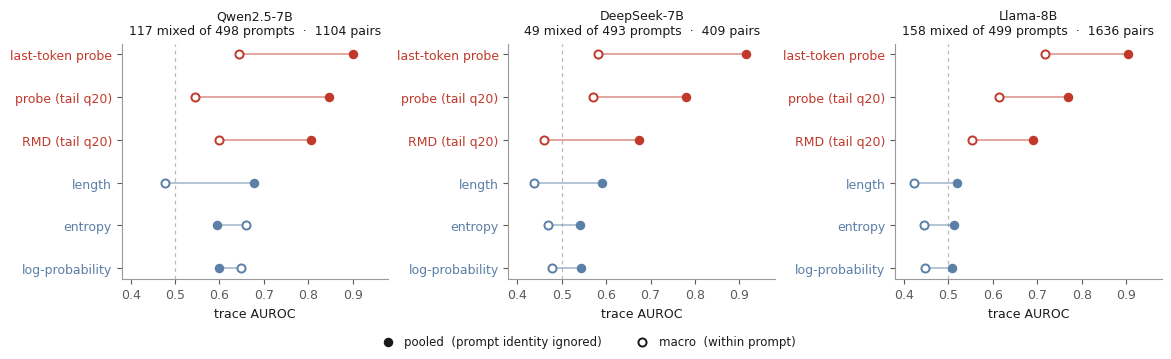

In [4]:
SCORES = [
    ("last_token_probe", "last-token probe", GEOMETRY),
    ("probe_hidden_tail_q20", "probe (tail q20)", GEOMETRY),
    ("rmd_tail_q20", "RMD (tail q20)", GEOMETRY),
    ("length", "length", OUTPUT_SIDE),
    ("mean_entropy", "entropy", OUTPUT_SIDE),
    ("mean_logprob", "log-probability", OUTPUT_SIDE),
]

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.5), sharex=True, constrained_layout=True)
for ax, label in zip(axes, MODELS):
    pop = PROBE["models"][label]["populations"]["parseable"]
    ys = np.arange(len(SCORES))[::-1]
    for y, (key, name, colour) in zip(ys, SCORES):
        point = pop["scores"][key]["point"]
        pooled, macro = point["pooled_auroc"], point["macro_prompt_auroc"]
        ax.plot([macro, pooled], [y, y], color=colour, lw=1.4, alpha=.45,
                zorder=1, solid_capstyle="butt")
        ax.scatter([pooled], [y], s=34, color=colour, zorder=3)
        ax.scatter([macro], [y], s=34, facecolor=PAPER, edgecolor=colour,
                   linewidth=1.4, zorder=3)
    ax.axvline(0.5, color="#b9b9b9", lw=.9, ls=(0, (3, 3)), zorder=0)
    ax.set_yticks(ys, [name for _, name, _ in SCORES])
    for tick, (_, _, colour) in zip(ax.get_yticklabels(), SCORES):
        tick.set_color(colour)
    ax.set_xlim(0.38, 0.98)
    ax.set_xlabel("trace AUROC")
    counts = pop["scores"]["last_token_probe"]["point"]
    ax.set_title(f"{NICE[label]}\n{counts['n_mixed_prompts']} mixed of "
                 f"{pop['n_prompts']} prompts  ·  "
                 f"{counts['n_within_prompt_pairs']} pairs", fontsize=9, pad=7)
handles = [
    axes[0].scatter([], [], s=34, color=INK,
                    label="pooled  (prompt identity ignored)"),
    axes[0].scatter([], [], s=34, facecolor=PAPER, edgecolor=INK, linewidth=1.4,
                    label="macro  (within prompt)"),
]
fig.legend(handles=handles, loc="outside lower center", ncol=2, fontsize=8.5,
           handletextpad=.4, columnspacing=2.4)
plt.show()

**Figure 1. Hidden-state scores lose more under prompt conditioning.** Filled dot =
pooled trace AUROC, hollow dot = macro within-prompt AUROC; the bar between them
is what conditioning on the prompt removes. Red is hidden-state, blue is
output-side. The panel titles carry the count that actually bounds the
within-prompt evidence: the macro dot on DeepSeek rests on 49 prompts, on Llama
on 158, and no bootstrap can widen 49 prompts into more information than they
hold. Two readings are visible and both matter. The three hidden-state scores
lose 0.14–0.33; entropy and log-probability lose about 0.06, and on Qwen they
cross over and score *higher* within prompt than pooled. Length also loses
0.10–0.20, so this is not a hidden-state-exclusive effect. The probe that wins
the pooled comparison by 30 points on Qwen (0.9013 against 0.5951) **loses** the
within-prompt one to entropy (0.6444 against 0.6602).

In [5]:
T3 = pd.DataFrame([
    {
        "model": NICE[label],
        "score": name,
        "family": "hidden state" if colour == GEOMETRY else "output side",
        "pooled": pop["scores"][key]["point"]["pooled_auroc"],
        "micro": pop["scores"][key]["point"]["micro_pair_auroc"],
        "macro": pop["scores"][key]["point"]["macro_prompt_auroc"],
        "pooled - macro": pop["scores"][key]["point"]["pooled_minus_macro"],
        "95% CI": "[{:+.4f}, {:+.4f}]".format(
            pop["scores"][key]["bootstrap"]["pooled_minus_macro"]["ci_low"],
            pop["scores"][key]["bootstrap"]["pooled_minus_macro"]["ci_high"]),
        "mixed prompts": pop["scores"][key]["point"]["n_mixed_prompts"],
        "pairs": pop["scores"][key]["point"]["n_within_prompt_pairs"],
    }
    for label in MODELS
    for pop in [PROBE["models"][label]["populations"]["parseable"]]
    for key, name, colour in SCORES
])
table(
    T3,
    "Table 3 · pooled, pair-weighted and prompt-weighted trace AUROC "
    "(population: parseable)",
    note=("The three columns are not defined on the same prompts, so the gap "
          "between them is a change of question and not a loss of precision. "
          "<code>parseable</code> drops unparsed traces to match the frozen "
          "probe's training rule -- keeping them lets a probe score by detecting "
          "truncation rather than reasoning failure. An interval that spans zero "
          "means that score's pooled number is not inflated, which is the "
          "result for entropy and log-probability on Qwen."),
    highlight=[row.score == "last-token probe" for row in T3.itertuples()],
    **{"pooled": "{:.4f}", "micro": "{:.4f}", "macro": "{:.4f}",
       "pooled - macro": "{:+.4f}"},
)

# Continuity: the reference scores here must reproduce the frozen
# prompt_decomposition report, or "same traces" is not true.
FROZEN = {"mean_entropy": (0.571, 0.559, 0.599, 0.595),
          "mean_logprob": (0.575, 0.559, 0.595, 0.589),
          "length": (0.737, 0.563, 0.581, 0.582),
          "rmd_tail_q20": (0.839, 0.640, 0.658, 0.653)}
here = PROBE["models"]["qwen"]["populations"]["all_traces"]["scores"]
print("Continuity with the frozen Qwen layer-21 report (population: all_traces)")
print(f"{'score':<16s} {'frozen':>28s}    {'here':>32s}")
for key, expected in FROZEN.items():
    point = here[key]["point"]
    got = (point["pooled_auroc"], point["prompt_centered_auroc"],
           point["macro_prompt_auroc"], point["micro_pair_auroc"])
    assert all(abs(a - b) < 1e-3 for a, b in zip(expected, got)), (key, expected, got)
    print(f"{key:<16s} {' / '.join(f'{v:.3f}' for v in expected):>28s}"
          f"    {' / '.join(f'{v:.4f}' for v in got):>32s}")
print("\npooled / prompt-centered / macro / micro. All four match, on all four "
      "columns.\nThat is load-bearing: pooled, micro and macro are rank "
      "statistics and cannot see\na monotone change of scale, but the "
      "prompt-centered column subtracts a per-prompt\nmean from the raw score "
      "and can. Reproducing three columns and missing the fourth\nis what a "
      "monotone mismatch looks like, and it is how the length score's "
      "transform\nwas caught. `length` is -log1p(token count), pinned by a test.")

from collections import Counter

LAYERS = pd.DataFrame([
    {"model": NICE[label],
     "layers offered": " / ".join(str(v) for v in PROBE["models"][label]["layers"]),
     "chosen, by fold": " · ".join(
         f"L{layer}×{count}" for layer, count in sorted(
             Counter(fold["selected_layer"] for fold in pop["folds"]).items())),
     "penalty C, by fold": " · ".join(
         f"{penalty:g}×{count}" for penalty, count in sorted(
             Counter(fold["selected_C"] for fold in pop["folds"]).items()))}
    for label in MODELS
    for pop in [PROBE["models"][label]["populations"]["parseable"]]
])
table(
    LAYERS,
    "Table 4 · in-fold layer and penalty selection, counted over the five "
    "outer folds",
    note=("Qwen reaching for the earliest offered layer in most folds is what "
          "prompt-difficulty encoding would look like -- but Llama selects its "
          "middle layer in every fold and DeepSeek mostly selects layer 14. The "
          "early-layer reading is Qwen's, not a general result, and is not "
          "evidence for the difficulty interpretation on its own. Layer and "
          "penalty were chosen together, inside the training split, by "
          "prompt-disjoint inner CV -- never on the split they are scored on."),
)

model,score,family,pooled,micro,macro,pooled - macro,95% CI,mixed prompts,pairs
Qwen2.5-7B,last-token probe,hidden state,0.9013,0.6214,0.6444,+0.2569,"[+0.1980, +0.3148]",117,1104
Qwen2.5-7B,probe (tail q20),hidden state,0.8474,0.5371,0.5460,+0.3014,"[+0.2306, +0.3656]",117,1104
Qwen2.5-7B,RMD (tail q20),hidden state,0.8069,0.5697,0.5984,+0.2085,"[+0.1441, +0.2693]",117,1104
Qwen2.5-7B,length,output side,0.6775,0.4534,0.4776,+0.1999,"[+0.1330, +0.2674]",117,1104
Qwen2.5-7B,entropy,output side,0.5951,0.6676,0.6602,-0.0651,"[-0.1383, +0.0033]",117,1104
Qwen2.5-7B,log-probability,output side,0.5983,0.6540,0.6494,-0.0511,"[-0.1250, +0.0179]",117,1104
DeepSeek-7B,last-token probe,hidden state,0.9139,0.6015,0.5823,+0.3316,"[+0.2260, +0.4499]",49,409
DeepSeek-7B,probe (tail q20),hidden state,0.7807,0.5501,0.5714,+0.2094,"[+0.1118, +0.3106]",49,409
DeepSeek-7B,RMD (tail q20),hidden state,0.6748,0.4621,0.4610,+0.2139,"[+0.1091, +0.3171]",49,409
DeepSeek-7B,length,output side,0.5916,0.4364,0.4365,+0.1551,"[+0.0418, +0.2730]",49,409


Continuity with the frozen Qwen layer-21 report (population: all_traces)
score                                  frozen                                here
mean_entropy     0.571 / 0.559 / 0.599 / 0.595    0.5708 / 0.5588 / 0.5992 / 0.5948
mean_logprob     0.575 / 0.559 / 0.595 / 0.589    0.5747 / 0.5594 / 0.5947 / 0.5892
length           0.737 / 0.563 / 0.581 / 0.582    0.7367 / 0.5629 / 0.5807 / 0.5820
rmd_tail_q20     0.839 / 0.640 / 0.658 / 0.653    0.8393 / 0.6396 / 0.6584 / 0.6527

pooled / prompt-centered / macro / micro. All four match, on all four columns.
That is load-bearing: pooled, micro and macro are rank statistics and cannot see
a monotone change of scale, but the prompt-centered column subtracts a per-prompt
mean from the raw score and can. Reproducing three columns and missing the fourth
is what a monotone mismatch looks like, and it is how the length score's transform
was caught. `length` is -log1p(token count), pinned by a test.


model,layers offered,"chosen, by fold","penalty C, by fold"
Qwen2.5-7B,7 / 14 / 21,L7×4 · L21×1,0.003×5
DeepSeek-7B,7 / 14 / 21,L14×4 · L21×1,0.001×4 · 0.003×1
Llama-8B,8 / 16 / 24,L16×5,0.001×4 · 0.003×1


## 4. What survives for the hidden-state score

Section 3 removes a claim the score was never entitled to. What is left is the
prompt-level one, and it is measured on a different unit: 500 prompts, not
4,000 traces, with the outcome aggregated over the eight samples. Nothing in the
within-prompt collapse touches it, because it never asked which sibling is
right.

`B0` is the target-only output baseline -- length, entropy, log-probability and
vote agreement. `B1` adds `rmd_tail_q20` and nothing else. Both are fitted the
same way on the same folds, so the contrast is the hidden-state feature.

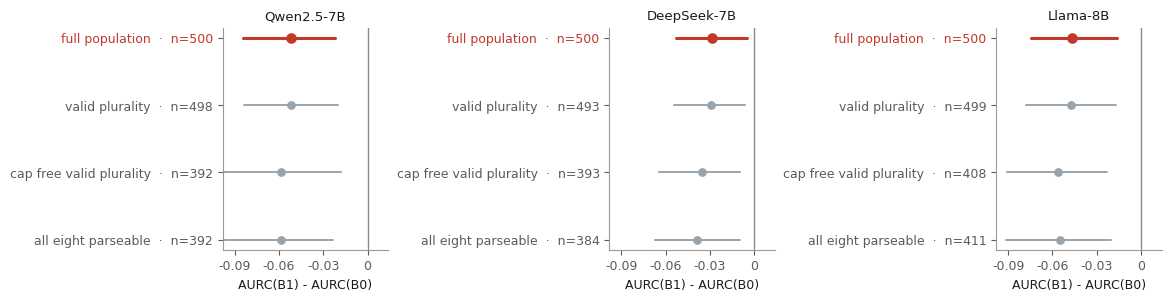

In [6]:
BY = {(row["model"], row["population"]): row for row in BUDGET["populations"]}
fig, axes = plt.subplots(1, 3, figsize=(11.6, 2.9), sharex=True, constrained_layout=True)
for ax, label in zip(axes, MODELS):
    ys = np.arange(len(ORDER))[::-1]
    for y, population in zip(ys, ORDER):
        row = BY[(label, population)]
        primary = population == PRIMARY
        colour = B1_COLOR if primary else "#9aa4ad"
        ax.plot([row["delta_ci_low"], row["delta_ci_high"]], [y, y],
                color=colour, lw=2.2 if primary else 1.4, solid_capstyle="round")
        ax.scatter([row["delta_estimate"]], [y], s=44 if primary else 28,
                   color=colour, zorder=3)
    ax.axvline(0, color="#8a8a8a", lw=1.0)
    # The prompt count rides on the tick label; as a separate annotation it
    # collides with either the zero rule or the tick text itself.
    ax.set_yticks(ys, [f"{population.replace('_', ' ')}  ·  "
                       f"n={BY[(label, population)]['n_prompts']}"
                       for population in ORDER])
    ax.get_yticklabels()[0].set_color(B1_COLOR)
    ax.set_xlabel("AURC(B1) - AURC(B0)")
    ax.set_title(NICE[label], fontsize=9.5, pad=6)
    ax.set_xlim(-0.098, 0.014)
    ax.set_xticks([-0.09, -0.06, -0.03, 0.0], ["-0.09", "-0.06", "-0.03", "0"])
plt.show()

**Figure 2. The increment, on every population, with the primary one marked.**
Negative is better: `B1` carries less area under the risk-coverage curve than
`B0`. The sign is the same on all twelve rows and every interval excludes zero,
so the estimand choice sets the *size* of the effect, not its existence. The
red row is `C_B` on all 500 prompts. Its magnitude is smaller than the cap-free
headline on every model, which is the honest direction for the result to move
when the conditioning is removed.

### 4a. Where in the trace, and how much of that is the localization

`B1` adds one score, and *where in the trace* it is measured is not a detail.
The paper-facing comparison is between the published whole-trace score and the
tail restriction used by `B1`:

| Region | Score |
|:--|:--|
| the whole trace | `rmd_full` -- **this is Vazhentsev et al.'s ATRMD, published prior art** |
| the final 20% of tokens | `rmd_tail_q20`, the feature `B1` uses |

Table 5a puts the tail against the published whole-trace score on the primary
population, and the answer is a **split, not a ranking**. On both distilled
models the untailed ATRMD collects essentially the entire increment and the
tail adds nothing measurable. On Qwen it is the reverse: ATRMD alone does not
clear zero over `B0`, and the tail collects all of it. The two scores correlate
at Pearson 0.931-0.957, so this is not two different signals -- it is the same
signal, needing a different region on a different architecture.

**So the claim is the increment, not the feature.** "A hidden-state Mahalanobis
score adds a prompt-level gain over target-only output features" replicates on
all three models. "The *tail* is where it has to be measured" does not: it is a
Qwen-specific refinement of an already-published score, it costs nothing, and
presenting it as the contribution would be claiming across models something
established on one. Stop rule `1b` pre-declared that no region or percentile
sweep follows whichever way this landed, and none has. The older comparison
with an entropy-selected region remains in notebook
[11](11_prompt_geometry_core_experiments.ipynb); it is not part of the paper
claim or this evidence package.

In [7]:
def interval(entry):
    return (f"{entry['point_estimate']:+.4f} "
            f"[{entry['ci_low']:+.4f}, {entry['ci_high']:+.4f}]")


# Table 5a is on the same scale and population as sections 2-4: risk against
# coverage, lower is better, C_B over all 500 prompts.
L = pd.DataFrame([
    {
        "model": NICE[m["label"]],
        "layer": m["layer"],
        "B1 - B0": interval(P["paired_deltas_aurc"]["B1_minus_B0"]),
        "ATRMD over B0": interval(P["paired_deltas_aurc"]["rmd_full_over_B0"]),
        "tail over ATRMD": interval(P["paired_deltas_aurc"]["rmd_tail_over_rmd_full"]),
        "corr(ATRMD, tail)": P["redundancy"]["rmd_full_vs_rmd_tail_q20"]["pearson"],
    }
    for m in CLOSEST["models"]
    for P in [m["populations"][PRIMARY]]
])
_clears = lambda d: d["ci_high"] < 0
table(
    L, "Table 5a &middot; the tail against the published whole-trace score, "
       f"{PRIMARY}",
    note=("<b>Lower is better; a negative delta favours the left-hand readout.</b> "
          "<code>rmd_full</code> is Vazhentsev et al.'s ATRMD, so the middle "
          "column asks what an already-published feature buys and the right one "
          "asks what the tail adds on top of it.<br><br>"
          "<b>The split.</b> ATRMD clears zero over <code>B0</code> on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                 ["rmd_full_over_B0"]))
          + " and not on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if not _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                     ["rmd_full_over_B0"]))
          + "; the tail clears zero over ATRMD on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                 ["rmd_tail_over_rmd_full"]))
          + " only. Exactly the models where one works are the models where the "
          "other does not, and the last column shows the two are near-collinear "
          "throughout. The increment is what replicates across models; the "
          "region it has to be read from is not.<br><br>"
          "Stop rule <code>1a</code> lives in the same artifact and does not "
          "trigger here either: the tail over <code>B0 + neg_answer_entropy</code> "
          "clears zero on "
          f"{sum(_clears(m['populations'][PRIMARY]['paired_deltas_aurc']['rmd_tail_over_B0_plus_H']) for m in CLOSEST['models'])}"
          " of 3 models, and the rule stops the claim at two failures."),
    **{"corr(ATRMD, tail)": "{:.2f}"},
)

model,layer,B1 - B0,ATRMD over B0,tail over ATRMD,"corr(ATRMD, tail)"
Qwen2.5-7B,21,"-0.0520 [-0.0832, -0.0218]","-0.0178 [-0.0435, +0.0105]","-0.0464 [-0.0724, -0.0224]",0.93
DeepSeek-7B,21,"-0.0284 [-0.0531, -0.0060]","-0.0287 [-0.0534, -0.0055]","-0.0030 [-0.0109, +0.0035]",0.96
Llama-8B,24,"-0.0469 [-0.0773, -0.0178]","-0.0445 [-0.0739, -0.0151]","-0.0041 [-0.0118, +0.0035]",0.94


These are **fixed-pipeline intervals** -- every interval in this notebook, the
table above included. They resample prompts with the folds, the layer and the
fitted coefficients all held at `seed=42`. That answers "a different set of
prompts to score", not "a different partition to fit on", and no number of
bootstrap draws converts one into the other. The gate below is the missing
piece.

In [8]:
if REFIT is None:
    display(HTML(
        f"<div style='background:#fdf6e3;border-left:3px solid #c9a227;"
        f"padding:11px 15px;font:400 12px/1.6 {SANS};color:{INK};max-width:780px'>"
        "<b>Gate open: full-refit stability is registered and pending.</b><br>"
        "Registered in <code>EXPERIMENT_LOG.md</code> (2026-08-22, "
        "<i>Refit stability -- registered before the sweep runs</i>), before any "
        "refit existed. The decision rule fixed there: a residual that changes "
        "sign across refits is demoted however tight its within-refit interval "
        "was; a stable sign with spread comparable to the bootstrap width leaves "
        "the claim standing and both are reported; a stable sign with materially "
        "wider spread means the refit spread replaces the reported interval."
        "<br><br>Until <code>results/refit_stability/</code> exists, every "
        "interval in this notebook is conditional on one partition, and the "
        "paper says so."
        "</div>"))
else:
    G = pd.DataFrame([
        {
            "model": NICE[label],
            "quantity": name.replace("_", " "),
            "refits": summary["n"],
            "mean": summary.get("mean"),
            "min": summary.get("min"),
            "max": summary.get("max"),
            "spread": summary.get("spread"),
            "sign stable": "yes" if summary.get("sign_stable") else "NO",
            "drift from seed 42": summary.get("max_abs_drift_from_frozen"),
        }
        for label in MODELS
        for name in ("b1_minus_b0_aurc", "probe_pooled_minus_macro",
                     "peer_residual_deployable_aurc")
        for summary in [REFIT["summary"][label][name]]
        if summary.get("n")
    ])
    table(
        G, f"Table 6 · full-refit stability over seeds {REFIT['seeds']}",
        note=("Each refit re-runs the pipeline end to end on a different prompt "
              "partition: OOF scores regenerated, prompt-level readouts "
              "refitted, the probe refitted including its in-fold layer and "
              "penalty choice, the peer ladder refitted across all models. "
              "Read against the decision rule registered before the sweep ran."),
        **{"mean": "{:+.4f}", "min": "{:+.4f}", "max": "{:+.4f}",
           "spread": "{:.4f}", "drift from seed 42": "{:.4f}"},
    )

## 5. What the same money buys from a peer model

`B1` adds no generations. The obvious challenge is that a second model's
disagreement, bought with real sampling, would do the same job. Turning that
into a comparison needs one distinction the earlier draft of this notebook did
not make.

A **graded** peer score is the fraction of the peer's drawn siblings that are
*correct*. It consults the gold answer, so it cannot be deployed; it is an
oracle diagnostic that bounds what the peer family could contribute. An
**agree** peer score is the fraction of the peer's siblings whose predicted
answer matches the target's plurality answer. No gold is consulted, so it is a
method someone could actually run.

The earlier reading of this notebook -- that peer controls absorb the increment,
and most of what `B1` adds is prompt difficulty -- rested on the graded score.
It is withdrawn. A gold-aware ceiling losing to nothing is not a baseline
beating anything.

One more piece of accounting: **no peer rung is cost-matched to `B1`.** `B1`
buys zero extra generations, but it is not free -- it needs retained hidden
states, an extraction pass and a fitted readout. The x-axis below counts
generations, which is the cost `B1` genuinely does not pay.

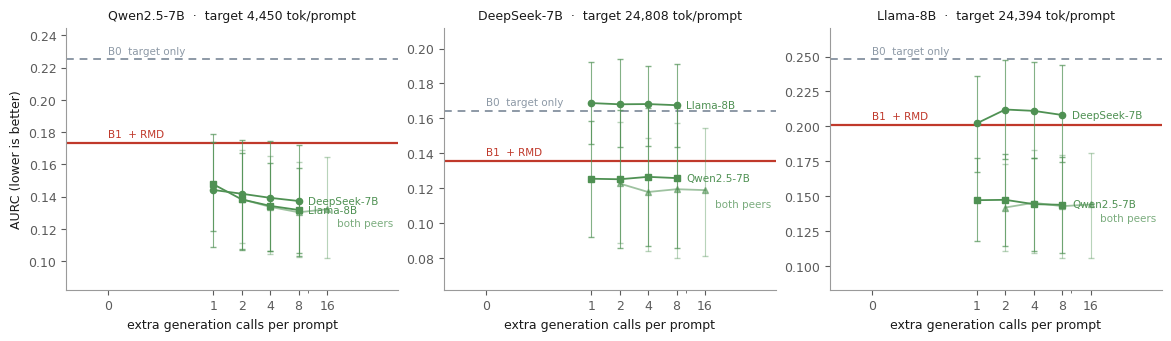

In [9]:
LADDER_BY = {m["label"]: m for m in LADDER["models"]}
SIZES = LADDER["ladder_sizes"]

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.3), sharey=False,
                         constrained_layout=True)
for ax, label in zip(axes, MODELS):
    entry = LADDER_BY[label]
    rungs = entry["populations"][PRIMARY]["rungs"]
    ax.axhline(rungs["B0"]["aurc_mean"], color=B0_COLOR, lw=1.4,
               ls=(0, (4, 3)), zorder=1)
    ax.axhline(rungs["B1"]["aurc_mean"], color=B1_COLOR, lw=1.6, zorder=1)
    ax.annotate("B0  target only", (0, rungs["B0"]["aurc_mean"]),
                xytext=(0, 4), textcoords="offset points", fontsize=7.5,
                color=B0_COLOR, ha="left")
    ax.annotate("B1  + RMD", (0, rungs["B1"]["aurc_mean"]),
                xytext=(0, 4), textcoords="offset points", fontsize=7.5,
                color=B1_COLOR, ha="left")
    for peer, marker in zip(entry["peers"] + ["both"], ["o", "s", "^"]):
        xs, ys, err_low, err_high = [], [], [], []
        for size in SIZES:
            name = f"B0_agree_{peer}_m{size}"
            rung = rungs.get(name)
            if rung is None:
                continue
            delta = entry["populations"][PRIMARY]["contrasts"][f"B1_minus_{name}"]["aurc"]
            xs.append(rung["cost"]["extra_calls"])
            ys.append(rung["aurc_mean"])
            err_low.append(delta["ci_high"] - delta["point_estimate"])
            err_high.append(delta["point_estimate"] - delta["ci_low"])
        faded = peer == "both"
        ax.plot(xs, ys, marker=marker, ms=4.5, lw=1.3, color=PEER_COLOR,
                alpha=.55 if faded else 1.0, zorder=2)
        ax.errorbar(xs, ys, yerr=[err_low, err_high], fmt="none",
                    color=PEER_COLOR, capsize=2, lw=.8,
                    alpha=.4 if faded else .7, zorder=1)
        # The combined rung ends one tick further right and often lands on top
        # of the single-peer label, so it is dropped a line.
        ax.annotate(NICE.get(peer, "both peers"), (xs[-1], ys[-1]),
                    xytext=(7, -10 if faded else 0), textcoords="offset points",
                    va="center", fontsize=7.5, color=PEER_COLOR,
                    alpha=.75 if faded else 1.0)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xticks([0, 1, 2, 4, 8, 16], ["0", "1", "2", "4", "8", "16"])
    ax.set_xlim(-0.4, 90)
    ax.set_xlabel("extra generation calls per prompt")
    ax.set_title(f"{NICE[label]}  ·  target {entry['target_tokens_per_prompt']:,.0f} "
                 f"tok/prompt", fontsize=9, pad=6)
    ax.margins(y=0.16)
axes[0].set_ylabel("AURC (lower is better)")
plt.show()

**Figure 3. The deployable ladder.** Only `agree` rungs appear -- these are the
peer scores that never see the gold answer. `B1` (red line) sits at zero extra
calls; `B0` (grey dashes) is the target-only baseline both are measured against.
Vertical bars are paired 95% intervals for each rung's difference from `B1`; a
bar crossing the red line is not distinguishable from `B1`.

The figure does not show a cost axis that `B1` sits at the top of. Most peer
point estimates are *below* `B1` from the very first extra generation, and the
tally below counts how many of those differences actually exclude zero. What
moves the comparison is **which peer**, not **how much of it**: Qwen as a peer
beats `B1` on Llama-8B at every rung, Llama as a peer loses to `B1` on
DeepSeek-7B at every rung, and going from 1 to 8 extra generations barely
shifts either. That is a real limit on peer disagreement as a baseline -- its
value is a property of the model pair, not something a budget buys -- and it is
also why no single rung can be called *the* peer baseline.

In [10]:
VERDICT = LADDER["cheapest_peer_verdict"]
WORDS = {"B1": "RMD wins", "peer": "peer wins", "tie": "tie"}


def verdict(delta):
    """The ladder's own rule, applied to a contrast: an interval spanning zero
    is a tie, whatever the point estimate does."""
    low, high = delta["ci_low"], delta["ci_high"]
    if low < 0 < high:
        return "tie"
    return "peer wins" if delta["point_estimate"] > 0 else "RMD wins"


LADDER_TALLY = {}
for label in MODELS:
    fp = LADDER_BY[label]["populations"][PRIMARY]
    for name in fp["rungs"]:
        if not name.startswith("B0_agree_"):
            continue
        outcome = verdict(fp["contrasts"][f"B1_minus_{name}"]["aurc"])
        LADDER_TALLY[outcome] = LADDER_TALLY.get(outcome, 0) + 1
print("Every deployable rung on the primary population "
      f"({sum(LADDER_TALLY.values())} rungs: 3 targets x 3 peer sets x "
      f"{len(SIZES)} sizes)")
for outcome, count in sorted(LADDER_TALLY.items(), key=lambda kv: -kv[1]):
    print(f"  {outcome:<12s} {count:>3}")
print("  -- all four RMD wins are DeepSeek-7B against Llama-8B peers, at every "
      "rung size.\n")
PRIMARY_PEER_P = {
    f"{label}:{name}": LADDER_BY[label]["populations"][PRIMARY]
        ["contrasts"][f"B1_minus_{name}"]["aurc"]["p_two_sided"]
    for label in MODELS
    for name, rung in VERDICT[label]["rungs"].items()
    if rung["kind"] == "agree"
}
PRIMARY_PEER_HOLM = holm_correction(PRIMARY_PEER_P)
rows = []
for label in MODELS:
    for name, rung in VERDICT[label]["rungs"].items():
        if rung["kind"] != "agree":
            continue
        key = f"{label}:{name}"
        delta = LADDER_BY[label]["populations"][PRIMARY]["contrasts"][f"B1_minus_{name}"]["aurc"]
        rows.append({
            "target": NICE[label],
            "peer (1 extra generation)": name.replace("B0_agree_", "").replace("_m1", ""),
            "AURC(B1) - AURC(rung)": rung["aurc_delta_B1_minus_rung"],
            "95% CI": f"[{rung['ci'][0]:+.4f}, {rung['ci'][1]:+.4f}]",
            "p raw": delta["p_two_sided"],
            "p Holm": PRIMARY_PEER_HOLM[key],
            "verdict": WORDS[rung["winner"]],
        })
T6 = pd.DataFrame(rows)
counts = T6["verdict"].value_counts()
table(
    T6,
    "Table 7 · the deployable comparison at one extra generation",
    note=(f"{counts.get('tie', 0)} ties, {counts.get('RMD wins', 0)} RMD win, "
          f"{counts.get('peer wins', 0)} peer win over {len(T6)} target-peer "
          "pairs. Negative favours <code>B1</code>. This six-test cheapest-rung "
          "family is the primary peer comparison; Holm correction leaves the same "
          "two non-null verdicts. At one extra generation the deployable peer is "
          "mostly indistinguishable, beats RMD once, and loses to it once."),
    highlight=[verdict != "tie" for verdict in T6["verdict"]],
    **{"AURC(B1) - AURC(rung)": "{:+.4f}", "p raw": "{:.3f}", "p Holm": "{:.3f}"},
)

T7 = pd.DataFrame([
    {
        "target": NICE[label],
        "graded peer (1 extra generation)": name.replace("B0_graded_", "").replace("_m1", ""),
        "AURC(B1) - AURC(rung)": rung["aurc_delta_B1_minus_rung"],
        "95% CI": f"[{rung['ci'][0]:+.4f}, {rung['ci'][1]:+.4f}]",
        "deployable": "no -- consults gold",
    }
    for label in MODELS
    for name, rung in VERDICT[label]["rungs"].items()
    if rung["kind"] == "graded"
])
table(
    T7,
    "Table 8 · diagnostic only: the gold-aware graded peer",
    note=("<b>Not a baseline.</b> The graded readout scores a peer's siblings "
          "against the gold answer, so no deployment can compute it. It is "
          "reported to bound what peer information could contribute if it were "
          "free and perfectly graded. Any claim that peers &ldquo;absorb&rdquo; "
          "or &ldquo;explain&rdquo; the increment came from this table and does "
          "not survive the distinction."),
    **{"AURC(B1) - AURC(rung)": "{:+.4f}"},
)

Every deployable rung on the primary population (36 rungs: 3 targets x 3 peer sets x 4 sizes)
  tie           16
  peer wins     16
  RMD wins       4
  -- all four RMD wins are DeepSeek-7B against Llama-8B peers, at every rung size.



target,peer (1 extra generation),AURC(B1) - AURC(rung),95% CI,p raw,p Holm,verdict
Qwen2.5-7B,deepseek,+0.0250,"[-0.0099, +0.0603]",0.170,0.510,tie
Qwen2.5-7B,deepseek_llama,+0.0250,"[-0.0014, +0.0540]",0.062,0.248,tie
DeepSeek-7B,deepseek_llama,-0.0341,"[-0.0576, -0.0108]",0.008,0.040,RMD wins
DeepSeek-7B,qwen,+0.0129,"[-0.0201, +0.0464]",0.408,0.816,tie
Llama-8B,deepseek,+0.0014,"[-0.0327, +0.0366]",0.878,0.878,tie
Llama-8B,qwen,+0.0544,"[+0.0240, +0.0838]",0.000,0.000,peer wins


target,graded peer (1 extra generation),AURC(B1) - AURC(rung),95% CI,deployable
Qwen2.5-7B,deepseek,+0.0520,"[+0.0271, +0.0828]",no -- consults gold
Qwen2.5-7B,deepseek_llama,+0.0238,"[-0.0034, +0.0514]",no -- consults gold
DeepSeek-7B,deepseek_llama,+0.0625,"[+0.0384, +0.0888]",no -- consults gold
DeepSeek-7B,qwen,+0.0589,"[+0.0253, +0.0920]",no -- consults gold
Llama-8B,deepseek,+0.0207,"[-0.0190, +0.0575]",no -- consults gold
Llama-8B,qwen,+0.0049,"[-0.0314, +0.0448]",no -- consults gold


## 6. What this claims, what it withdraws, and what is still open

**The claim.** On MATH-500 under a fixed eight-sample protocol, a hidden-state
Mahalanobis score adds a small prompt-level selective-prediction gain over
target-only output features, at zero additional generations, on three
checkpoints, two reasoning-distilled. **The increment is the claim; the
localization is not.**
Which region of the trace supplies it splits by architecture -- on the two
distilled models the published whole-trace ATRMD supplies essentially all of
it, on Qwen only the tail does (section 4a, Table 5a) -- so `rmd_tail_q20` is a
cheap choice that works everywhere, not an established contribution. Its pooled
trace AUROC -- and that of a last-token probe
reproduced at full strength -- substantially conflates prompt difficulty with
trace correctness, so neither is established as a trace verifier. A deployable
peer-agreement baseline is a genuine competitor rather than a control: it is
mostly indistinguishable at the cheapest rung. The broader 36-rung tally is
exploratory because its nested comparisons are correlated and unadjusted. The
case for the score is that it is free of extra generations, not that it is the
strongest available signal.

**Withdrawn from the previous version of this notebook.** Each of these was
stated here before the closure experiments, and each is now contradicted by a
committed artifact rather than merely softened:

| Withdrawn claim | Why |
|:--|:--|
| the score is read from *a single forward pass* | it is computed over retained states of eight generated traces; the "no extra generations" property is real, the "one pass" framing is not |
| capped rows are *censored observations, not failures* | at a stated budget an unfinished trace is the protocol's outcome; treating it as missing conditions on the budget under evaluation |
| peer pass rates *absorb roughly four fifths* of the increment | that used the **graded** peer score, which consults the gold answer; the deployable `agree` score does not reproduce it |
| *most of the increment is prompt difficulty* | same source, same defect; the deployable comparison at one extra generation is 4 ties, 1 win, 1 loss |
| peer models are only a non-deployable control | `agree` rungs are deployable and are now the primary comparison; `graded` is the diagnostic |
| *tail localization is what replicates* | it replicates in the weak sense of never losing, but the untailed ATRMD -- published prior art -- collects the whole increment on both distilled models, and the tail is load-bearing on Qwen alone (section 4a) |

**Open.** The full outer refit (section 4's gate) is registered and pending;
until it lands, every interval here is conditional on one prompt partition. The
scope is one dataset, one budget, one layer per model, and three checkpoints
from two architecture families. That layer is the pre-specified deepest probe
layer at roughly two-thirds depth, and the L7/14/21 grid it is drawn from is not
arbitrary: a dense 14-layer sweep found the geometry signal **bimodal** in
depth -- peaks near L6-L10 and L20-L26 with a trough at L14 -- so the grid
samples both peaks and the trough rather than the last layer alone
([archived notebook 02](archive/02_layer_dynamics.ipynb); Qwen MATH-500 only,
and whether the bimodality replicates on the distill models is untested). Nothing here isolates *why* the hidden-state
scores encode difficulty, and the Qwen early-layer selection is a single-model
observation, not evidence for a mechanism. The same n=1 problem applies to
section 4a's localization split: it falls along the distilled/non-distilled
axis, and there is one non-distilled model in the set, so "distilled models do
not need the tail" is a description of these three checkpoints and not a
finding about distillation.

**How to falsify it.** Run the decomposition on a benchmark where most prompts
produce mixed outcomes -- the within-prompt readouts here rest on 117, 49 and
158 prompts, and a dataset with more of them could show the collapse shrinking.
Or find a hidden-state readout that keeps its pooled margin under macro
conditioning; nothing in the design forbids one existing.

### Provenance

- Experiment ledger, protocol and every correction: [`EXPERIMENT_LOG.md`](../EXPERIMENT_LOG.md)
- Paper strategy: [`PAPER_STRATEGY_RMD.md`](../PAPER_STRATEGY_RMD.md)
- Budget-indexed outcomes: [`results/budget_outcomes/`](../results/budget_outcomes/README.md)
- Peer cost ladder: [`results/peer_cost_ladder/`](../results/peer_cost_ladder/README.md)
- Closest baselines, stop rules 1a and 1b: [`results/closest_baselines/`](../results/closest_baselines/README.md)
- Last-token probe: [`results/last_token_probe/`](../results/last_token_probe/README.md)
- Refit stability (registered, pending): `controls/refit_stability.py`
- Every closure artifact, loaded: [notebook 17](17_rmd_experiment_ledger.ipynb)
- Long-form abstention detail: [notebook 12](12_wave1_abstention.ipynb)
- DeepConf null and label efficiency: [notebook 13](13_deepconf_null_and_label_efficiency.ipynb)